# Exploratory Data Analysis — Jigsaw Toxic Comment Dataset

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
LABELS = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}/")

Figures will be saved to: figures/


In [11]:
# Load train set
train = pd.read_csv("data/train.csv")

# Load test set (merge comments + labels, drop unlabelled rows)
test_comments = pd.read_csv("data/test.csv")
test_labels   = pd.read_csv("data/test_labels.csv")
test = test_comments.merge(test_labels[test_labels.toxic != -1], on="id", how="inner")

print(f"Train : {train.shape[0]:,} rows")
print(f"Test  : {test.shape[0]:,} labelled rows  ({len(test_labels[test_labels.toxic==-1]):,} unlabelled dropped)")

Train : 159,571 rows
Test  : 63,978 labelled rows  (89,186 unlabelled dropped)


In [12]:
summary = pd.DataFrame({
    "Split": ["Train", "Test (labelled)"],
    "Rows": [len(train), len(test)],
    "Toxic rows": [train[LABELS].any(axis=1).sum(), test[LABELS].any(axis=1).sum()],
    "Clean rows": [(~train[LABELS].any(axis=1)).sum(), (~test[LABELS].any(axis=1)).sum()],
})
summary["Toxic %"] = (summary["Toxic rows"] / summary["Rows"] * 100).round(1)
summary

,Split,Rows,Toxic rows,Clean rows,Toxic %
0,Train,159571,16225,143346,10.2
1,Test (labelled),63978,6243,57735,9.8


## 2. Label Distribution (Train)

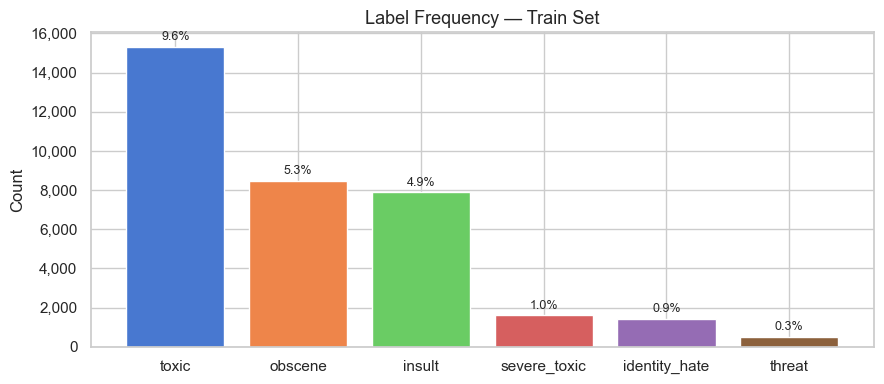

,count,pct (%)
toxic,15294,9.58
obscene,8449,5.29
insult,7877,4.94
severe_toxic,1595,1.00
identity_hate,1405,0.88
threat,478,0.30


In [13]:
counts = train[LABELS].sum().sort_values(ascending=False)
pcts   = counts / len(train) * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(counts.index, counts.values, color=sns.color_palette("muted", len(LABELS)))
ax.set_title("Label Frequency — Train Set", fontsize=13)
ax.set_ylabel("Count")
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/label_distribution.png", dpi=150)
plt.show()

pd.DataFrame({"count": counts, "pct (%)": pcts.round(2)})

## 3. Multi-label Distribution

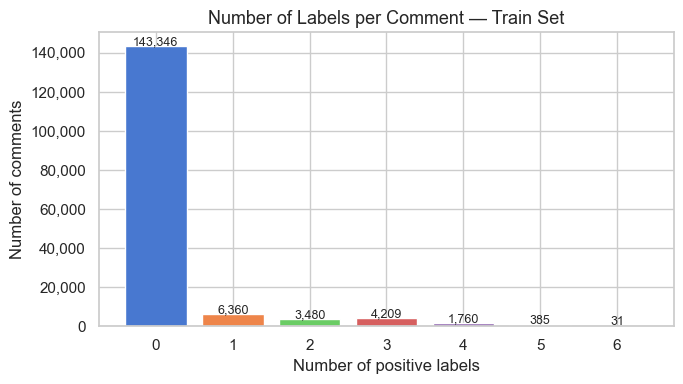

In [14]:
label_counts = train[LABELS].sum(axis=1).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(label_counts.index.astype(str), label_counts.values, color=sns.color_palette("muted"))
ax.set_title("Number of Labels per Comment — Train Set", fontsize=13)
ax.set_xlabel("Number of positive labels")
ax.set_ylabel("Number of comments")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (idx, val) in enumerate(label_counts.items()):
    ax.text(i, val + 500, f"{val:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/multilabel_distribution.png", dpi=150)
plt.show()

## 4. Label Co-occurrence Heatmap

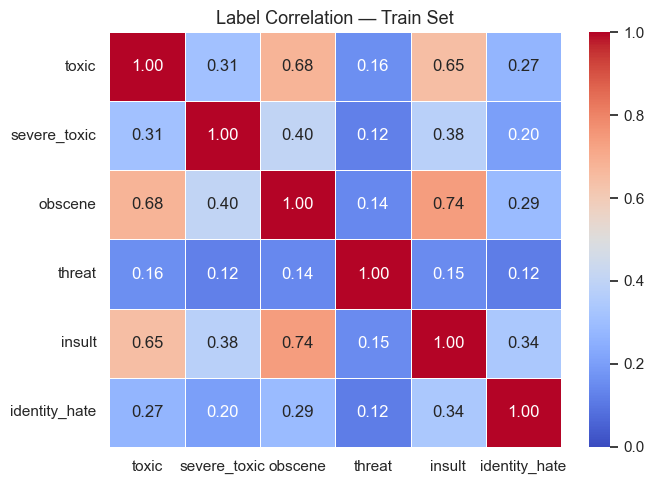

In [15]:
corr = train[LABELS].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Label Correlation — Train Set", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/label_correlation.png", dpi=150)
plt.show()

## 5. Comment Length Distribution

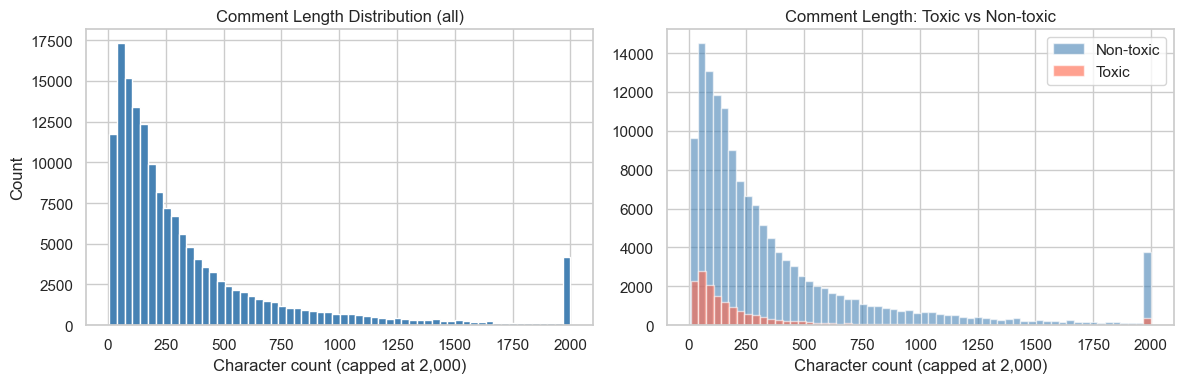

,count,mean,std,min,25%,50%,75%,max
is_toxic,,,,,,,,
False,143346.0,404.3,586.5,6.0,102.0,216.0,452.0,5000.0
True,16225.0,303.3,619.4,8.0,61.0,128.0,283.0,5000.0


In [16]:
train["char_len"] = train["comment_text"].str.len()
is_toxic = train[LABELS].any(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train["char_len"].clip(upper=2000), bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Comment Length Distribution (all)", fontsize=12)
axes[0].set_xlabel("Character count (capped at 2,000)")
axes[0].set_ylabel("Count")

for label, mask, color in [("Non-toxic", ~is_toxic, "steelblue"), ("Toxic", is_toxic, "tomato")]:
    axes[1].hist(train.loc[mask, "char_len"].clip(upper=2000), bins=60,
                 alpha=0.6, label=label, color=color, edgecolor="white")
axes[1].set_title("Comment Length: Toxic vs Non-toxic", fontsize=12)
axes[1].set_xlabel("Character count (capped at 2,000)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/comment_length.png", dpi=150)
plt.show()

train.groupby(is_toxic.rename("is_toxic"))["char_len"].describe().round(1)

## 6. Sample Comments per Label

In [17]:
for label in LABELS:
    sample = (train[train[label] == 1]["comment_text"]
              .sample(2, random_state=42)
              .reset_index(drop=True))
    print(f"\n{'='*60}")
    print(f"  {label.upper()}")
    print(f"{'='*60}")
    for i, text in enumerate(sample, 1):
        print(f"[{i}] {text[:300]}")


  TOXIC
[1] Hi! 

I wanna rape you!
[2] Terrorize 
I will terrorise you for as long as you live - you are an arrogant, disgusting and rude excuse for a human being & you are going to die soon so I suggest you stop threatening people you bastard.

  SEVERE_TOXIC
[1] "

 WHAT  IN THE FUCK ARE YOU REFERRING TOO 

I HAVE NO IDEA WHAT THE PISS YOU'RE REFERRING TOO, OR WHY YOU BOTHERED TO WRITE ME.  LISTEN I'VE ADDED PLENTY TO THESE PAGE INCLUDING A ""SMASHING"" ARTICLE ON SMASHED GLADYS...BUT THAT REALLY ISNT ANY OF YOU BUSSINESS NOW IS IT.  IF SOMEBODY HAS A PROBL
[2] takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  takes it up the arse.  t

  OBSCENE
[1] You are an utter fucking faggot...u need a life outside of wikipedia...maybe a didlo fuk by ur mom?
[2] WTF! 

u